# Decoy Analysis for Acarbose Alternatives

**Project:** Acarbose Alternative Drug Discovery  
**Notebook Purpose:** Analyze docking performance between putative active leads and property-matched decoy molecules.   

**Key Questions**
- How stable are CNN-VS scores across property-matched decoys?
- Do leads outperform property matched decoys in CNN-VS?

## 1. Setup & Imports

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from aadd import load_and_process_gnina

In [54]:
def extract_active_smiles(
    coconut_csv,
    active_ids_txt,
    out_smi_txt,
    id_col="identifier",
    smiles_col="canonical_smiles",
    verbose=True
):
    """
    Subset COCONUT-style CSV to active IDs and write SMILES to file.

    Parameters
    ----------
    coconut_csv : str
        Path to CSV containing candidate molecules
    active_ids_txt : str
        Text file with one active identifier per line
    out_smi_txt : str
        Output file to write canonical SMILES
    id_col : str, default="identifier"
        Column name for molecule identifiers
    smiles_col : str, default="canonical_smiles"
        Column name for SMILES
    verbose : bool, default=True
        Print IDs missing from coconut_csv

    Returns
    -------
    subset : pd.DataFrame
        DataFrame of active molecules found in coconut_csv
    missing_ids : list
        Active IDs not found in coconut_csv
    """

    # load data
    coconut = pd.read_csv(coconut_csv)

    # load active IDs
    with open(active_ids_txt) as f:
        active_ids = [line.strip() for line in f if line.strip()]

    active_id_set = set(active_ids)
    coconut_id_set = set(coconut[id_col])

    # check missing
    missing_ids = sorted(active_id_set - coconut_id_set)
    if verbose:
        for mid in missing_ids:
            print(f"{mid} is missing.")

    # subset
    subset = coconut[coconut[id_col].isin(active_id_set)]

    # write SMILES
    with open(out_smi_txt, "w") as f:
        for smi in subset[smiles_col]:
            f.write(f"{smi}\n")

    return subset, missing_ids


In [55]:
subset_2qmj, missing_2qmj = extract_active_smiles(
    coconut_csv="../high_similarity_candidates.csv",
    active_ids_txt="2qmj_active_ids.txt",
    out_smi_txt="2qmj_active_smi.txt"
)

subset_3baj, missing_3baj = extract_active_smiles(
    coconut_csv="../high_similarity_candidates.csv",
    active_ids_txt="3baj_active_ids.txt",
    out_smi_txt="3baj_active_smi.txt"
)

subset_5nn8, missing_5nn8 = extract_active_smiles(
    coconut_csv="../high_similarity_candidates.csv",
    active_ids_txt="5nn8_active_ids.txt",
    out_smi_txt="5nn8_active_smi.txt"
)

In [56]:
with open('5nn8_active_ids.txt') as f:
    active_ids_5nn8 = [line.strip() for line in f if line.strip()]
with open('3baj_active_ids.txt') as f:
    active_ids_3baj = [line.strip() for line in f if line.strip()]
with open('2qmj_active_ids.txt') as f:
    active_ids_2qmj = [line.strip() for line in f if line.strip()]

## 2. Data Loading

In [57]:
def query_map(active_ids: list):
    query_to_cid_map = {}
    for i, id in enumerate(active_ids):
        query_to_cid_map[f'Query_{i+1}'] = id
    
    return query_to_cid_map


In [58]:
qmap_2qmj = query_map(active_ids_2qmj)
qmap_3baj = query_map(active_ids_3baj)
qmap_5nn8 = query_map(active_ids_5nn8)

id_to_qmap_2qmj = {k: v for v, k in qmap_2qmj.items()}
id_to_qmap_3baj = {k: v for v, k in qmap_3baj.items()}
id_to_qmap_5nn8 = {k: v for v, k in qmap_5nn8.items()}

In [59]:
decoys_2qmj_smi = pd.read_csv('../Generated_decoys_2qmj_active_smi.csv')
decoys_3baj_smi = pd.read_csv('../Generated_decoys_3baj_active_smi.csv')
decoys_5nn8_smi = pd.read_csv('../Generated_decoys_5nn8_active_smi.csv')

In [60]:
decoys_2qmj_smi['coconut_id'] = decoys_2qmj_smi['Query'].map(qmap_2qmj)
decoys_3baj_smi['coconut_id'] = decoys_3baj_smi['Query'].map(qmap_3baj)
decoys_5nn8_smi['coconut_id'] = decoys_5nn8_smi['Query'].map(qmap_5nn8)

For the decoy datasets, I'm using a modified decoy 'identifier' that follows the general patttern: `[COCONUT_ID]_Decoy_[#]`.

In [61]:
decoys_2qmj_smi['identifier'] = (
    decoys_2qmj_smi['coconut_id']
    + '_Decoy_'
    + (decoys_2qmj_smi.index + 1).astype(str)
)

decoys_3baj_smi['identifier'] = (
    decoys_3baj_smi['coconut_id']
    + '_Decoy_'
    + (decoys_3baj_smi.index + 1).astype(str)
)

decoys_5nn8_smi['identifier'] = (
    decoys_5nn8_smi['coconut_id']
    + '_Decoy_'
    + (decoys_5nn8_smi.index + 1).astype(str)
)

In [62]:
decoys_2qmj_data = load_and_process_gnina('../2qmj_decoys.parquet')
decoys_3baj_data = load_and_process_gnina('../3baj_decoys.parquet')
decoys_5nn8_data = load_and_process_gnina('../5nn8_decoys.parquet')

In [63]:
decoys_2qmj = pd.merge(decoys_2qmj_smi, decoys_2qmj_data, on='identifier', how='right')
decoys_3baj = pd.merge(decoys_3baj_smi, decoys_3baj_data, on='identifier', how='right')
decoys_5nn8 = pd.merge(decoys_5nn8_smi, decoys_5nn8_data, on='identifier', how='right')

In [64]:
decoys_2qmj['coconut_id'] = decoys_2qmj['identifier'].str.split('_').str[0]
decoys_3baj['coconut_id'] = decoys_3baj['identifier'].str.split('_').str[0]
decoys_5nn8['coconut_id'] = decoys_5nn8['identifier'].str.split('_').str[0]

In [65]:
decoys_2qmj['Query'] = decoys_2qmj['coconut_id'].map(id_to_qmap_2qmj)
decoys_3baj['Query'] = decoys_3baj['coconut_id'].map(id_to_qmap_3baj)
decoys_5nn8['Query'] = decoys_5nn8['coconut_id'].map(id_to_qmap_3baj)

In [66]:
leads_2qmj = load_and_process_gnina('../2qmj_vs.parquet')
leads_3baj = load_and_process_gnina('../3baj_vs.parquet')
leads_5nn8 = load_and_process_gnina('../5nn8_vs.parquet')


leads_2qmj = leads_2qmj[leads_2qmj['cnn_vs'] >= 6.30]
leads_3baj = leads_3baj[leads_3baj['cnn_vs'] >= 6.30]
leads_5nn8 = leads_5nn8[leads_5nn8['cnn_vs'] >= 6.30]

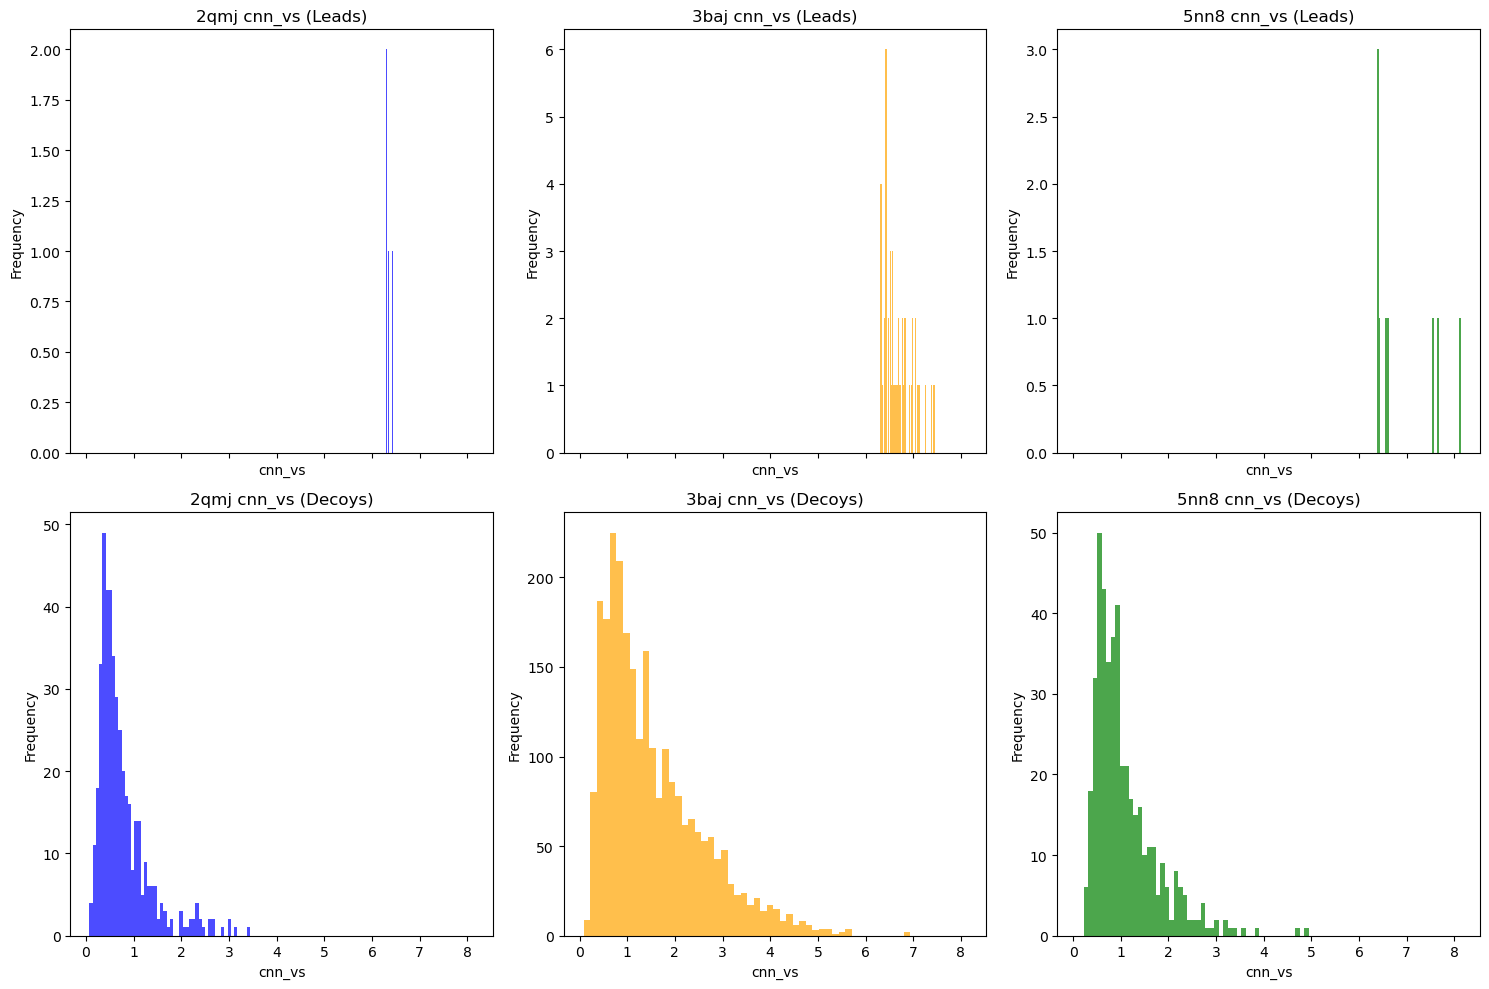

In [67]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
axs[0, 0].hist(leads_2qmj['cnn_vs'], bins=50, color='blue', alpha=0.7)
axs[0, 0].set_title('2qmj cnn_vs (Leads)')
axs[0, 1].hist(leads_3baj['cnn_vs'], bins=50, color='orange', alpha=0.7)
axs[0, 1].set_title('3baj cnn_vs (Leads)')
axs[0, 2].hist(leads_5nn8['cnn_vs'], bins=50, color='green', alpha=0.7)
axs[0, 2].set_title('5nn8 cnn_vs (Leads)')
axs[1, 0].hist(decoys_2qmj['cnn_vs'], bins=50, color='blue', alpha=0.7)
axs[1, 0].set_title('2qmj cnn_vs (Decoys)')
axs[1, 1].hist(decoys_3baj['cnn_vs'], bins=50, color='orange', alpha=0.7)
axs[1, 1].set_title('3baj cnn_vs (Decoys)')
axs[1, 2].hist(decoys_5nn8['cnn_vs'], bins=50, color='green', alpha=0.7)
axs[1, 2].set_title('5nn8 cnn_vs (Decoys)')
for ax in axs.flat:
    ax.set_xlabel('cnn_vs')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

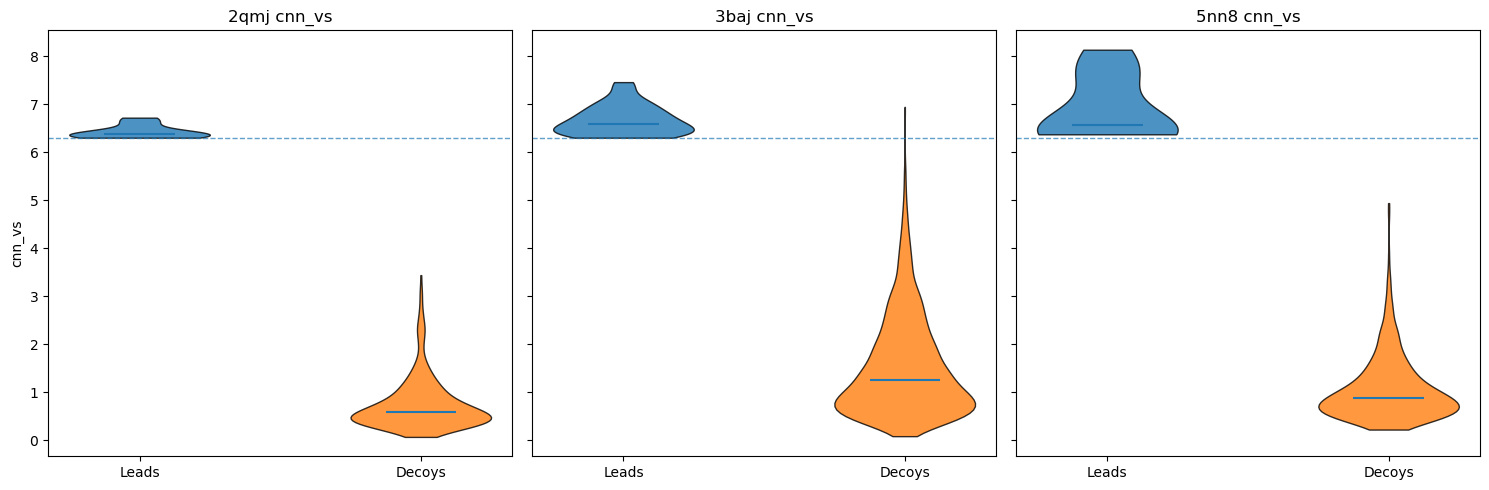

In [68]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# (leads, decoys, title)
data = [
    (leads_2qmj['cnn_vs'], decoys_2qmj['cnn_vs'], '2qmj'),
    (leads_3baj['cnn_vs'], decoys_3baj['cnn_vs'], '3baj'),
    (leads_5nn8['cnn_vs'], decoys_5nn8['cnn_vs'], '5nn8'),
]

lead_color  = 'tab:blue'
decoy_color = 'tab:orange'
threshold   = 6.30

for ax, (leads, decoys, title) in zip(axs, data):
    parts = ax.violinplot(
        [leads, decoys],
        positions=[1, 2],
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    # color violins explicitly
    for i, body in enumerate(parts['bodies']):
        body.set_facecolor(lead_color if i == 0 else decoy_color)
        body.set_edgecolor('black')
        body.set_alpha(0.8)

    # dashed threshold line
    ax.axhline(threshold, linestyle='--', linewidth=1, alpha=0.7)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Leads', 'Decoys'])
    ax.set_title(f'{title} cnn_vs')

axs[0].set_ylabel('cnn_vs')
plt.tight_layout()
plt.show()


## 3. Analysis

### 3.1. Adjusted p-values and robust z-values.

Here, we compute a one-sided emprical p-value of each ligand compared with ~50 property-matched decoys, adjusted using the BH-FDR. We also determine how many standard deviations the ligands' CNN-VS lays above the decoys' median.

In [69]:
def p_and_z(df, leads_df, z_val=False):
    cid = df["coconut_id"].iloc[0]

    x = leads_df.loc[
        leads_df["identifier"] == cid, "cnn_vs"
    ].item()

    s = df["cnn_vs"]
    r = (s > x).sum()
    n = len(s)

    empirical_p = (r + 1) / (n + 1)
    z_robust = (x - s.median()) / (1.4826 * (s - s.mean()).abs().mean())
    
    if z_val:
        return empirical_p, z_robust
    else:
        return (r + 1) / (n + 1)

def bh_qvalues(pvals: pd.Series) -> pd.Series:
    p = pvals.astype(float).values
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * m / (np.arange(1, m+1))
    
    # enforce monotonicity from the back + cap at 1
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty(m)
    out[order] = q
    return pd.Series(out, index=pvals.index)

In [70]:
# 2QMJ
p_vals_2qmj = (
    decoys_2qmj
    .groupby("coconut_id", group_keys=False)
    .apply(p_and_z, leads_df=leads_2qmj)
)

bh_qvals_2qmj = bh_qvalues(p_vals_2qmj)
sig = (bh_qvals_2qmj < 0.05)
bh_qvals_2qmj = pd.concat([bh_qvals_2qmj, sig], axis=1)

# 3BAJ
p_vals_3baj = (
    decoys_3baj
    .groupby("coconut_id", group_keys=False)
    .apply(p_and_z, leads_df=leads_3baj)
)

bh_qvals_3baj = bh_qvalues(p_vals_3baj)
sig = (bh_qvals_3baj < 0.05)
bh_qvals_3baj = pd.concat([bh_qvals_3baj, sig], axis=1)

# 5NN8
p_vals_5nn8 = (
    decoys_5nn8
    .groupby("coconut_id", group_keys=False)
    .apply(p_and_z, leads_df=leads_5nn8)
)

bh_qvals_5nn8 = bh_qvalues(p_vals_5nn8)
sig = (bh_qvals_5nn8 < 0.05)
bh_qvals_5nn8 = pd.concat([bh_qvals_5nn8, sig], axis=1)

/var/folders/kw/ddpd6dfs6sl6s1nvpt91qqnr0000gn/T/ipykernel_42990/4146643065.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(p_and_z, leads_df=leads_2qmj)
/var/folders/kw/ddpd6dfs6sl6s1nvpt91qqnr0000gn/T/ipykernel_42990/4146643065.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(p_and_z, leads_df=leads_3baj)
/var/folders/kw/ddpd6dfs6sl6s1nvpt91qqnr0000gn/T/ipykernel_42990/4146643065.py:

In [82]:
bh_qvals_3baj

,0,1
coconut_id,,
CNP0032127.0,0.022569,True
CNP0064234.1,0.022569,True
CNP0064234.2,0.200000,False
CNP0073554.1,0.040784,True
CNP0086794.3,0.022569,True
CNP0101894.1,0.022569,True
CNP0103968.1,0.022569,True
CNP0146019.1,0.022569,True
CNP0146238.1,0.022569,True


### 3.2. Ligand rank dominance analysis

Here, we want to see if and how often the lead molecules outperform the decoys; for a decoy set this small in size, we're ideally seeing top-1 ranking for all ligands, but we can expland this into a more forgiving percentile range.

In [75]:
def lead_rank(df, leads_df):
    
    # tale the first one
    cid = df["coconut_id"].iloc[0]

    # lead score
    x = leads_df.loc[
        leads_df["identifier"] == cid, "cnn_vs"
    ].item()

    # decoy scores
    s = df["cnn_vs"]

    # combine: lead + decoys
    combined = pd.concat(
        [
            pd.Series([x], name="cnn_vs", index=["__lead__"]),
            s.reset_index(drop=True)
        ]
    )

    # ranking
    ranks = combined.rank(ascending=False, method="min")

    lead_rank = int(ranks.loc["__lead__"])
    is_top_1 = lead_rank == 1

    return pd.Series({
        "lead_rank": lead_rank,
        "is_top_1": is_top_1,
        "is_top_3": lead_rank <= 3,
        "is_top_5": lead_rank <= 5,
        "lead_percentile": 1 - (lead_rank - 1) / len(combined),
        "n_total": len(combined)
    })


In [76]:
# 2QMJ 
lead_rank_vals_2qmj = (
    decoys_2qmj
    .groupby("coconut_id", group_keys=False)
    .apply(lead_rank, leads_df=leads_2qmj)
)


lead_rank_vals_3baj = (
    decoys_3baj
    .groupby("coconut_id", group_keys=False)
    .apply(lead_rank, leads_df=leads_3baj)
)


lead_rank_vals_5nn8 = (
    decoys_5nn8
    .groupby("coconut_id", group_keys=False)
    .apply(lead_rank, leads_df=leads_5nn8)
)

/var/folders/kw/ddpd6dfs6sl6s1nvpt91qqnr0000gn/T/ipykernel_42990/2747151478.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lead_rank, leads_df=leads_2qmj)
/var/folders/kw/ddpd6dfs6sl6s1nvpt91qqnr0000gn/T/ipykernel_42990/2747151478.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lead_rank, leads_df=leads_3baj)
/var/folders/kw/ddpd6dfs6sl6s1nvpt91qqnr0000gn/T/ipykernel_42990/2747151478

In [85]:
lead_rank_vals_3baj

,lead_rank,is_top_1,is_top_3,is_top_5,lead_percentile,n_total
coconut_id,,,,,,
CNP0032127.0,1,True,True,True,1.000000,51
CNP0064234.1,1,True,True,True,1.000000,50
CNP0064234.2,1,True,True,True,1.000000,5
CNP0073554.1,2,False,True,True,0.980000,50
CNP0086794.3,1,True,True,True,1.000000,50
CNP0101894.1,1,True,True,True,1.000000,51
CNP0103968.1,1,True,True,True,1.000000,51
CNP0146019.1,1,True,True,True,1.000000,50
CNP0146238.1,1,True,True,True,1.000000,50


## 4. Results & Interpretation

* All lead ligands binding to 2QMJ and 5NN8, adjusted p-values < 0.05.
* Out of 53 lead ligands binding to 3BAJ, one (CNP0064234.2) had adjusted p-value > 0.05.
  * We cannot reject the null hypothesis that this ligand's CNN-VS score comes from the same distribution as the decoys'.
* All lead ligands binding 2QMJ and 5NN8 ranked 1st (CNN-VS) amongst property matched decoys.
* Of the 53 lead ligands binding to 3BAJ, only two (CNP0073554.1 & CNP0174709.1) were not top-1 ranking amongst their decoy set; both ligands ranked second.

Overall, all leads from 2QMJ and 5NN8 pass the decoy test, and while CNP0073554.1 & CNP0174709.1 may not rank #1 amongst their decoys, this may be a result of GNINA-seed based variance. The only candidate that requires deeper scrutiny is CNP0064234.2, which did not pass our initial statistical test.